<a href="https://colab.research.google.com/github/varshamqa/AIML_Practice_Repo_VSC1/blob/main/AIML_Sequential_VM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
sentences = [
    "I love machine learning",
    "I love deep learning",
    "machine learning is powerful",
    "deep learning is powerful",
    "machine learning is amazing",
    "deep learning is amazing",
    "artificial intelligence is powerful",
    "artificial intelligence is amazing",
    "machine learning is changing the world",
    "deep learning is changing the world",
    "artificial intelligence is changing the world",
    "students are learning machine learning",
    "students are learning deep learning",
    "developers are building intelligent systems",
    "machine learning helps solve problems",
    "artificial intelligence helps solve problems"
]

print("Number of sentences:", len(sentences))

Number of sentences: 16


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)
word_index = tokenizer.word_index

vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size:", vocab_size)
print("Word Index:", word_index)


Vocabulary Size: 23
Word Index: {'learning': 1, 'is': 2, 'machine': 3, 'deep': 4, 'artificial': 5, 'intelligence': 6, 'powerful': 7, 'amazing': 8, 'changing': 9, 'the': 10, 'world': 11, 'are': 12, 'i': 13, 'love': 14, 'students': 15, 'helps': 16, 'solve': 17, 'problems': 18, 'developers': 19, 'building': 20, 'intelligent': 21, 'systems': 22}


In [4]:
tokenizer.texts_to_sequences(["Machine Learning is powerful"])

[[3, 1, 2, 7]]

In [5]:
input_sequences = []
for sentence in sentences:
    token_list = tokenizer.texts_to_sequences([sentence])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print("Total Sequences:", len(input_sequences))
print("Total Sequences:", input_sequences)

Total Sequences: 59
Total Sequences: [[13, 14], [13, 14, 3], [13, 14, 3, 1], [13, 14], [13, 14, 4], [13, 14, 4, 1], [3, 1], [3, 1, 2], [3, 1, 2, 7], [4, 1], [4, 1, 2], [4, 1, 2, 7], [3, 1], [3, 1, 2], [3, 1, 2, 8], [4, 1], [4, 1, 2], [4, 1, 2, 8], [5, 6], [5, 6, 2], [5, 6, 2, 7], [5, 6], [5, 6, 2], [5, 6, 2, 8], [3, 1], [3, 1, 2], [3, 1, 2, 9], [3, 1, 2, 9, 10], [3, 1, 2, 9, 10, 11], [4, 1], [4, 1, 2], [4, 1, 2, 9], [4, 1, 2, 9, 10], [4, 1, 2, 9, 10, 11], [5, 6], [5, 6, 2], [5, 6, 2, 9], [5, 6, 2, 9, 10], [5, 6, 2, 9, 10, 11], [15, 12], [15, 12, 1], [15, 12, 1, 3], [15, 12, 1, 3, 1], [15, 12], [15, 12, 1], [15, 12, 1, 4], [15, 12, 1, 4, 1], [19, 12], [19, 12, 20], [19, 12, 20, 21], [19, 12, 20, 21, 22], [3, 1], [3, 1, 16], [3, 1, 16, 17], [3, 1, 16, 17, 18], [5, 6], [5, 6, 16], [5, 6, 16, 17], [5, 6, 16, 17, 18]]


In [6]:
max_sequence_length = max(len(sequence) for sequence in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_sequence_length, padding='pre')
# print("Max Sequence Length:", max_sequence_length)
print("Padded Sequences:", input_sequences.shape)

Padded Sequences: (59, 6)


In [7]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

In [8]:
model = Sequential([
    Embedding(input_dim= vocab_size, output_dim = 32),
    LSTM(64),
    Dense(vocab_size, activation='softmax')
])

In [9]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(X, y, epochs = 100, verbose = 1)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0847 - loss: 3.1360
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2034 - loss: 3.1270
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2542 - loss: 3.1181
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2712 - loss: 3.1076
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3051 - loss: 3.0968
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3559 - loss: 3.0829
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3559 - loss: 3.0670
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3559 - loss: 3.0488
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3559 - loss: 3.0240
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3559 - loss: 2.9929
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3220 - loss: 2.9544
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2542 - lo

In [12]:
import matplotlib.pyplot as plt

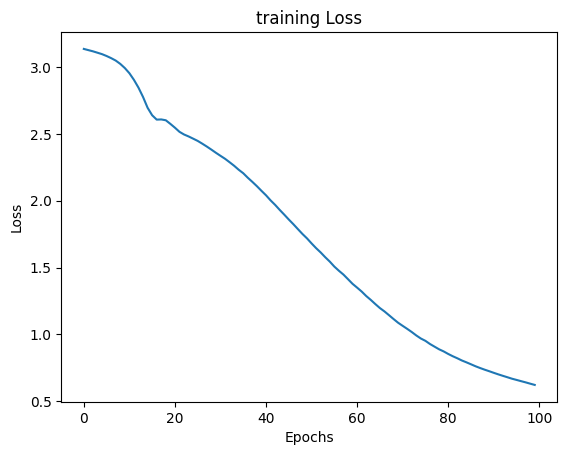

In [13]:
plt.plot(history.history["loss"])
plt.title("training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [14]:
def predict_next_word(seed_text):
  token_list = tokenizer.texts_to_sequences([seed_text])[0]
  token_list = pad_sequences([token_list], maxlen=max_sequence_length-1, padding='pre')
  predictions = model.predict(token_list, verbose = 0)
  predicted_token = np.argmax(predictions, axis = -1)[0]
  for word, index in tokenizer.word_index.items():
    if index == predicted_token:
      return word

In [15]:
test_inputs = [

    "I love machine",

    "I love deep",

    "machine learning is",

    "deep learning is",

    "artificial intelligence is"

]

In [16]:
for text in test_inputs:
  next_word = predict_next_word(text)
  print(f"{text} {next_word}")
#

I love machine learning
I love deep learning
machine learning is powerful
deep learning is powerful
artificial intelligence is amazing


In [17]:
def generate_text(seed_text, number_of_words):
  generated_text = seed_text
  for _ in range(number_of_words):
    next_word = predict_next_word(generated_text)
    generated_text += " " + next_word
  return generated_text

In [18]:
print(generate_text("Artificial Intelligence", 4))

Artificial Intelligence is amazing the world
